In [24]:
"""
Second attempt at training the models. We change the rng for the train/test. We used here for the label division 
NTSS < 3.5 - crypt < 50. 
The seed of the split is set to 11, while the random state for the shuffled of the cross validation is set to 15.

"""

'\nSecond attempt at training the models. We change the rng for the train/test. We used here for the label division \nNTSS < 3.5 - crypt < 50. \nThe seed of the split is set to 11, while the random state for the shuffled of the cross validation is set to 15.\n\n'

In [25]:
"""
=== PREZADO TEST SET ===
Selected papers (5):
  - FLASH Proton RT Mitigates Inflammatory and Fibrotic Pathways  (1 samples)
  - Proton-FLASH: effects on an in-vivo mouse ear model  (2 samples)
  - First demonstration of the FLASH effect with ultrahigh dose-rate high-energy X-rays  (3 samples)
  - Neuroprotection of radiosensitive juvenile mice by ultra-high dose rate flash  (1 samples)
  - The constant low oxygen concentration in all the target cells for mouse tail radionecrosis  (4 samples)
Total samples in PREZADO test: 11

=== TOSCHINI TEST SET ===
Selected papers (1):
  - Anesthetic Oxygen Use and Sex Are Critical Factors  (1 samples)
Total samples in TOSCHINI test: 1

=== GLOBAL SPLIT SUMMARY ===
Original dataset size: 85
Train samples: 73
Test samples:  12
Excluded group 'Ruan et al., 2021' kept in TRAIN: 21 samples
Check: train + test = 85
"""

"\n=== PREZADO TEST SET ===\nSelected papers (5):\n  - FLASH Proton RT Mitigates Inflammatory and Fibrotic Pathways  (1 samples)\n  - Proton-FLASH: effects on an in-vivo mouse ear model  (2 samples)\n  - First demonstration of the FLASH effect with ultrahigh dose-rate high-energy X-rays  (3 samples)\n  - Neuroprotection of radiosensitive juvenile mice by ultra-high dose rate flash  (1 samples)\n  - The constant low oxygen concentration in all the target cells for mouse tail radionecrosis  (4 samples)\nTotal samples in PREZADO test: 11\n\n=== TOSCHINI TEST SET ===\nSelected papers (1):\n  - Anesthetic Oxygen Use and Sex Are Critical Factors  (1 samples)\nTotal samples in TOSCHINI test: 1\n\n=== GLOBAL SPLIT SUMMARY ===\nOriginal dataset size: 85\nTrain samples: 73\nTest samples:  12\nExcluded group 'Ruan et al., 2021' kept in TRAIN: 21 samples\nCheck: train + test = 85\n"

In [26]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [27]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

test = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "elec-prot_test.xlsx"
)

In [28]:
train = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "augmented_3.xlsx"
)

In [29]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X_train = train[features]
y_train = train["Endpoint"]

X_test = test[features]
y_test = test["Endpoint"]

titles = train["Title"]

In [30]:
# RANDOM FOREST

In [31]:
from src.models.random_forest import train_random_forest
model = train_random_forest(X_train, y_train, n = 2000, msl = 10, mss = 20)

In [32]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model, X_train, y_train, titles, seed=15)


=== Fold composition summary ===

Fold 1:
  Train groups: 14
  Test groups:  3
  Train samples: 192
  Test samples:  100

Fold 2:
  Train groups: 14
  Test groups:  3
  Train samples: 244
  Test samples:  48

Fold 3:
  Train groups: 13
  Test groups:  4
  Train samples: 244
  Test samples:  48

Fold 4:
  Train groups: 15
  Test groups:  2
  Train samples: 256
  Test samples:  36

Fold 5:
  Train groups: 12
  Test groups:  5
  Train samples: 232
  Test samples:  60



{'f1_scores': array([0.9       , 0.89655172, 0.57142857, 0.43478261, 0.5       ]),
 'accuracy_scores': array([0.84      , 0.875     , 0.75      , 0.27777778, 0.5       ]),
 'f1_mean': np.float64(0.6605525808524308),
 'f1_std': np.float64(0.19885822224376587),
 'acc_mean': np.float64(0.6485555555555556),
 'acc_std': np.float64(0.2270523951061886)}

In [33]:
from src.models.evaluation import evaluate_model
evaluate_model(model, X_test, y_test)

{'accuracy': 0.75,
 'f1': 0.4,
 'confusion_matrix': array([[8, 0],
        [3, 1]]),
 'fpr': array([0.   , 0.   , 0.25 , 0.25 , 0.75 , 0.75 , 0.875, 0.875, 1.   ]),
 'tpr': array([0.  , 0.25, 0.25, 0.5 , 0.5 , 0.75, 0.75, 1.  , 1.  ]),
 'roc_auc': 0.53125}

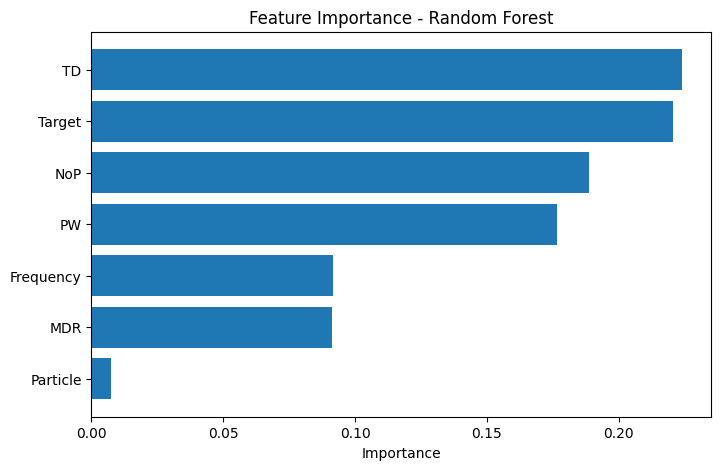

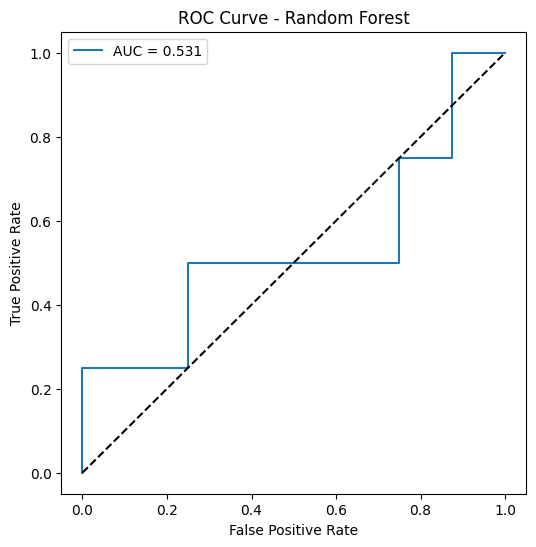

In [34]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance = get_feature_importance(model, features)
plot_feature_importance(feature_importance, "Random Forest")
plot_roc_curve(model, X_test, y_test, "Random Forest")

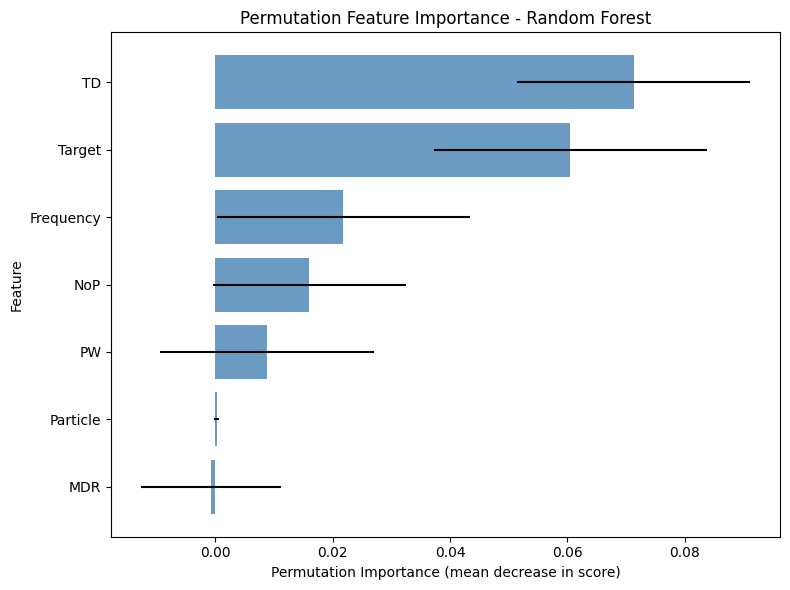

In [35]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True,
    model_name="Random Forest"
)


In [36]:
# XGBOOST

In [37]:
from src.models.xgboost import train_xgb

model_xgb = train_xgb(X_train, y_train, n=500, md = 4, ra= 0.1, rl = 2)

In [38]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model_xgb, X_train, y_train, titles, seed=15)


=== Fold composition summary ===

Fold 1:
  Train groups: 14
  Test groups:  3
  Train samples: 192
  Test samples:  100

Fold 2:
  Train groups: 14
  Test groups:  3
  Train samples: 244
  Test samples:  48

Fold 3:
  Train groups: 13
  Test groups:  4
  Train samples: 244
  Test samples:  48

Fold 4:
  Train groups: 15
  Test groups:  2
  Train samples: 256
  Test samples:  36

Fold 5:
  Train groups: 12
  Test groups:  5
  Train samples: 232
  Test samples:  60



{'f1_scores': array([0.72268908, 0.76190476, 0.4       , 0.5       , 0.6031746 ]),
 'accuracy_scores': array([0.67      , 0.6875    , 0.5       , 0.33333333, 0.58333333]),
 'f1_mean': np.float64(0.5975536881419234),
 'f1_std': np.float64(0.13508953853146788),
 'acc_mean': np.float64(0.5548333333333334),
 'acc_std': np.float64(0.12941792766073798)}

In [39]:
from src.models.evaluation import evaluate_model
evaluate_model(model_xgb, X_test, y_test)

{'accuracy': 0.5833333333333334,
 'f1': 0.2857142857142857,
 'confusion_matrix': array([[6, 2],
        [3, 1]]),
 'fpr': array([0.   , 0.   , 0.5  , 0.5  , 0.75 , 0.75 , 0.875, 0.875, 1.   ]),
 'tpr': array([0.  , 0.25, 0.25, 0.5 , 0.5 , 0.75, 0.75, 1.  , 1.  ]),
 'roc_auc': 0.46875}

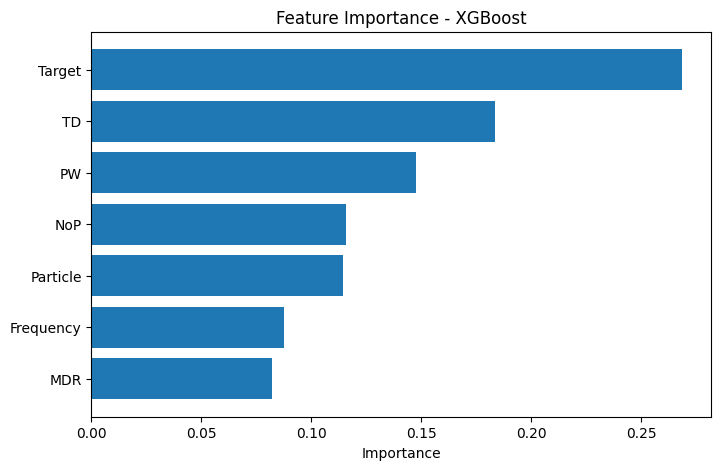

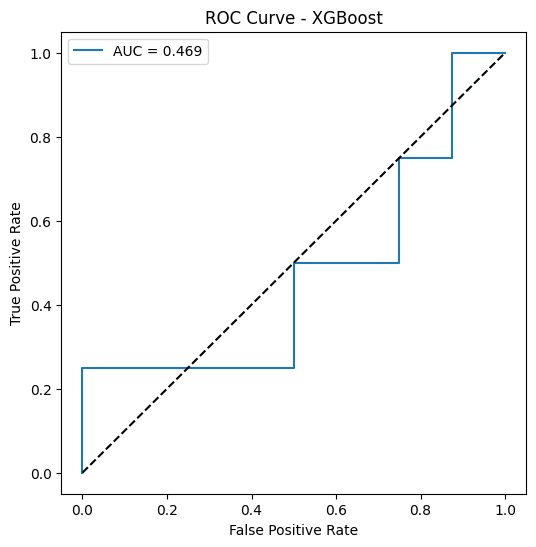

In [40]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance_xgb = get_feature_importance(model_xgb, features)
plot_feature_importance(feature_importance_xgb, "XGBoost")
plot_roc_curve(model_xgb, X_test, y_test, "XGBoost")

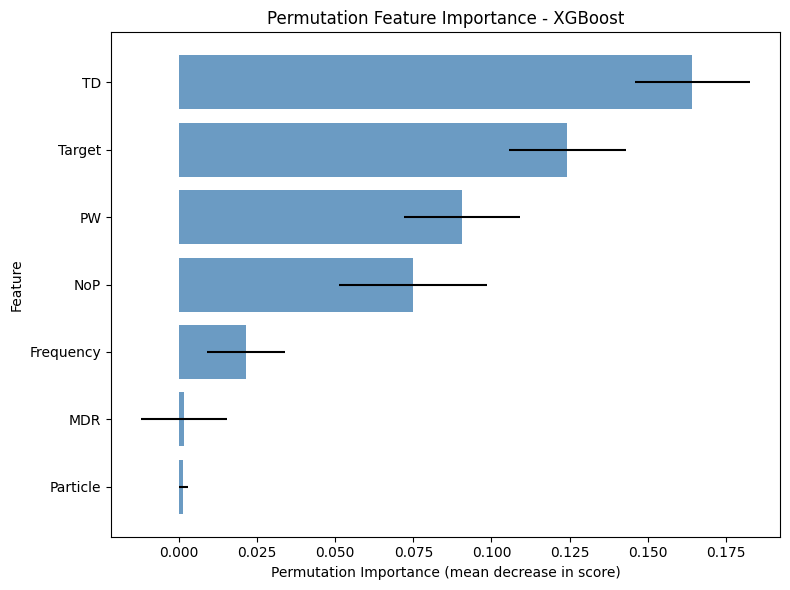

In [41]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model_xgb,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True,
    model_name="XGBoost"
)

In [42]:
# Neural Network

In [43]:
"""
from src.models.neural_network import build_mlp
model_nn = build_mlp(input_dim=X_train.shape[1])
"""

'\nfrom src.models.neural_network import build_mlp\nmodel_nn = build_mlp(input_dim=X_train.shape[1])\n'

In [44]:
"""
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train
)


from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    validation_data=(X_test_nn, y_test_nn),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=1
)
"""

"\nfrom sklearn.model_selection import train_test_split\n\nX_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(\n    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train\n)\n\n\nfrom tensorflow.keras.callbacks import EarlyStopping\nes = EarlyStopping(\n    monitor='val_loss',\n    patience=20,\n    restore_best_weights=True\n)\n\nhistory = model_nn.fit(\n    X_train, y_train,\n    validation_data=(X_test_nn, y_test_nn),\n    epochs=200,\n    batch_size=32,\n    callbacks=[es],\n    verbose=1\n)\n"

In [45]:
"""
from src.models.evaluation import evaluate_model_keras
evaluate_model_keras(model_nn, X_test, y_test)
"""

'\nfrom src.models.evaluation import evaluate_model_keras\nevaluate_model_keras(model_nn, X_test, y_test)\n'